# Question 8. 
In the lab, a classification tree was applied to the Carseats data set after converting Sales into a qualitative response variable. Now we will seek to predict Sales using regression trees and related approaches, treating the response as a quantitative variable.

In [1]:
from ISLP import load_data
import numpy as np

Carseats = load_data('Carseats')
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


## (a)  
Split the data set into a training set and a test set.

In [2]:
import numpy as np
import pandas as pd
import sklearn.model_selection as skm
from ISLP.models import ModelSpec as MS

model = MS(Carseats.columns.drop('Sales'),intercept=False)
D = model.fit_transform(Carseats)
feature_name = list(D.columns)
X = np.asarray(D)
y = Carseats['Sales']

(X_train,X_test,y_train,y_test) = skm.train_test_split(X,Carseats['Sales'])

## (b)  
Fit a regression tree to the training set. Plot the tree, and interpret the results. What test MSE do you obtain?

[Text(0.6807758935083881, 0.9705882352941176, 'ShelveLoc[Good] <= 0.5\nsquared_error = 8.177\nsamples = 300\nvalue = 7.527'),
 Text(0.4475747629467542, 0.9117647058823529, 'Price <= 124.5\nsquared_error = 5.974\nsamples = 231\nvalue = 6.72'),
 Text(0.5641753282275711, 0.9411764705882353, 'True  '),
 Text(0.23422684172137126, 0.8529411764705882, 'Advertising <= 6.5\nsquared_error = 5.11\nsamples = 150\nvalue = 7.462'),
 Text(0.09375, 0.7941176470588235, 'ShelveLoc[Medium] <= 0.5\nsquared_error = 3.683\nsamples = 77\nvalue = 6.479'),
 Text(0.053428154631655726, 0.7352941176470589, 'Age <= 63.5\nsquared_error = 3.025\nsamples = 26\nvalue = 5.184'),
 Text(0.04266958424507659, 0.6764705882352942, 'Education <= 17.5\nsquared_error = 2.603\nsamples = 17\nvalue = 5.826'),
 Text(0.03282275711159737, 0.6176470588235294, 'Income <= 94.5\nsquared_error = 1.979\nsamples = 15\nvalue = 6.11'),
 Text(0.02188183807439825, 0.5588235294117647, 'Education <= 11.5\nsquared_error = 1.558\nsamples = 12\nvalu

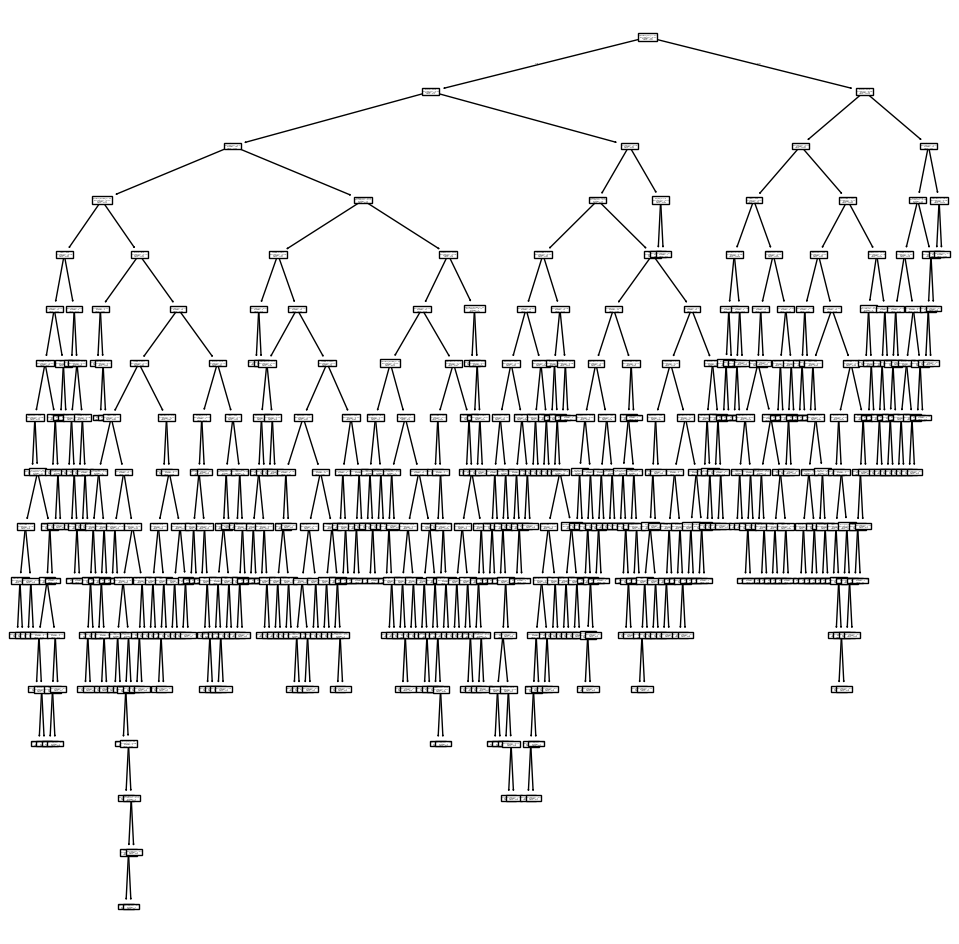

In [5]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text
                          )
from matplotlib.pyplot import subplots

reg = DTR(random_state=16)
reg.fit(X_train, y_train)
fig, ax = subplots(figsize=(12,12))
plot_tree(reg, feature_names=feature_name,ax=ax)

In [6]:
from sklearn.metrics import mean_squared_error

y_pred = reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mse

6.064544

## (c)  
Use cross-validation in order to determine the optimal level of tree complexity. Does pruning the tree improve the test MSE?

In [9]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train) 
ccp_alphas = ccp_path.ccp_alphas

print(f'We found a total of {len(ccp_alphas)} distinct ccp_alpha values (complexity levels).')

We found a total of 291 distinct ccp_alpha values (complexity levels).


In [10]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, make_scorer

kfold = KFold(n_splits=10, random_state=42, shuffle=True)
param_grid = {'ccp_alpha': ccp_alphas}
neg_mse_scorer = 'neg_mean_squared_error'

grid_search = GridSearchCV(reg, 
                           param_grid, 
                           cv=kfold, 
                           scoring=neg_mse_scorer,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=16)
,param_grid,{'ccp_alpha': array([0.0000...17893529e+00])}
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [21]:
best_alpha = grid_search.best_params_['ccp_alpha']

best_neg_mse_cv = grid_search.best_score_
best_mse_cv = -best_neg_mse_cv

print(f"Best ccp_alpha : {best_alpha:.4f}")
print(f"Best MSE after pruning: {best_mse_cv:.4f}")

no_pruning_idx = np.where(grid_search.cv_results_['param_ccp_alpha'].data == 0)[0][0]
no_pruning_mse = -grid_search.cv_results_['mean_test_score'][no_pruning_idx]

print(f"Best MSE before pruning: {no_pruning_mse:.4f}")

Best ccp_alpha : 0.0911
Best MSE after pruning: 5.1684
Best MSE before pruning: 6.1034


## (d)  
Use the bagging approach in order to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important.

In [24]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

bag_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42), 
    n_estimators=500,
    random_state=42, 
    n_jobs=-1
)

bag_reg.fit(X_train, y_train)
y_pred_bag = bag_reg.predict(X_test)

test_mse_bag = mean_squared_error(y_test, y_pred_bag)

print(f"MSE from bagging: {test_mse_bag:.4f}")

MSE from bagging: 2.5632


In [31]:
n_features = X_train.shape[1]
importance_sum = np.zeros(n_features)

for tree in bag_reg.estimators_:
    importance_sum += tree.feature_importances_

avg_importance = importance_sum / bag_reg.n_estimators
                                       
importance_df = pd.DataFrame({
    'Feature': feature_name,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=False)


print("Importance from bagging：")
print(importance_df.head(5).to_markdown(index=False))

Importance from bagging：
| Feature         |   Importance |
|:----------------|-------------:|
| Price           |     0.270935 |
| ShelveLoc[Good] |     0.26724  |
| CompPrice       |     0.107766 |
| Advertising     |     0.104829 |
| Age             |     0.083582 |


## (e) 
Use random forests to analyze this data. What test MSE do you obtain? Use the feature_importance_ values to determine which variables are most important. Describe the effect of m, the number of variables considered at each split, on the error rate
obtained.

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

n_features = X_train.shape[1] 
m_value = int(n_features / 3) 

rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_features=m_value,
    random_state=16,
    n_jobs=-1
)

rf_reg.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
y_pred_rf = rf_reg.predict(X_test)

test_mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"MSE from random forest: {test_mse_rf:.4f}")

MSE from random forest: 3.2057


## (f) 
Now analyze the data using BART, and report your results.

In [43]:
from ISLP.bart import BART 
from sklearn.metrics import mean_squared_error
import numpy as np

bart_model = BART(
    num_trees=50,
    ndraw=2000,
    burnin=500,
    random_state=16
)

bart_model.fit(X_train, y_train)

,num_trees,50
,num_particles,10
,max_stages,5000
,split_prob,<function BAR...001EF8C851760>
,min_depth,0
,std_scale,2
,split_prior,None
,ndraw,2000
,burnin,500
,sigma_prior,"(5, ...)"
,num_quantile,50


In [44]:
y_pred_bart_samples = bart_model.predict(X_test)

In [46]:
y_pred_bart_samples.shape

(100,)

In [48]:
y_pred_bart_final = bart_model.predict(X_test)

y_test_flat = np.ravel(y_test)
y_pred_bart_flat = np.ravel(y_pred_bart_final)
test_mse_bart = mean_squared_error(y_test_flat, y_pred_bart_flat)
print(f"MSE from BART: {test_mse_bart:.4f}")

MSE from BART: 1.6684
